# Profile retrieval — exact mutation profile posterior

## 목표
동일한 전체 변이 프로필이 **outer-fold train**에 다시 등장할 때만 class posterior를 조회해 H0를 보수적으로 보완합니다. 전처리·posterior·class prior는 fold-train에서만 fit합니다.

## 고정 조건과 규칙
- 기준 H0: self-contained LR 0.80 + automatic hard-specialist LGBM 0.20
- retrieval posterior: profile count + prior strength 1.0
- 결합: 일치 행만 `0.80 × H0 + 0.20 × posterior`; 불일치 행은 H0 유지
- seed42 Stratified 5-fold. test는 읽지 않으며, train/test concat·고정 gene/class/mutation 규칙·threshold 탐색을 하지 않습니다.
- NaN·WT·빈 문자열은 event가 아니며 `nan_as_mutation_count == 0`을 결과에 기록합니다.

실행 순서: 설정 → 실행 → 결과 확인. 전체 실행은 H0를 fold마다 재학습하므로 시간이 걸릴 수 있습니다.

In [1]:
from pathlib import Path
import subprocess, sys
from tqdm.auto import tqdm

ROOT = Path('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton')
RUNNER = ROOT / 'experiments/gs/notebooks/exp_model_006/common/run_profile_retrieval.py'
RESULT = ROOT / 'experiments/gs/notebooks/exp_model_006/result'
RUN_ID = 'exp-profile-retrieval-01'
RUN_EXPERIMENT = True
assert RUNNER.exists()
print({'runner': RUNNER, 'result_dir': RESULT, 'seed': 42, 'test_read': False, 'profile_blend_weight': 0.20})

{'runner': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model_006/common/run_profile_retrieval.py'), 'result_dir': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model_006/result'), 'seed': 42, 'test_read': False, 'profile_blend_weight': 0.2}


/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
if RUN_EXPERIMENT:
    process = subprocess.Popen([sys.executable, str(RUNNER), '--run-id', RUN_ID], stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    tail = []
    for line in tqdm(process.stdout, desc='profile retrieval folds', unit='line'):
        print(line, end='')
        tail = (tail + [line])[-120:]
    if process.wait():
        raise RuntimeError('Profile retrieval runner failed:\n' + ''.join(tail))
else:
    print('RUN_EXPERIMENT=False: 기존 result만 읽습니다.')

profile retrieval folds: 1line [00:05,  5.21s/line]

[profile-retrieval] outer fold 1/5: fit H0 and profile lookup


profile retrieval folds: 2line [03:13, 112.89s/line]

[profile-retrieval] outer fold 2/5: fit H0 and profile lookup


profile retrieval folds: 3line [06:58, 164.08s/line]

...

profile retrieval folds: 5line [14:05, 194.81s/line]

[profile-retrieval] outer fold 5/5: fit H0 and profile lookup


profile retrieval folds: 6line [17:32, 198.96s/line]

{"seed": 42, "outer_splits": 5, "profile_prior_strength": 1.0, "profile_blend_weight": 0.2, "test_read": false, "train_test_concat": false, "fixed_class_gene_mutation_rules": false, "profile_vocabulary_source": "outer_fold_train_only", "leakage_check": true, "nan_as_mutation_count": 0, "runtime_seconds": 1050.74301604199, "low_margin_delta": -0.023157818978009004, "decision": "rejected", "delta_vs_h0": -0.00702103482986427, "positive_fold_count": 0, "matched_rate": 0.12062570553136591, "retrieval_recovered_rows": 3, "retrieval_broken_rows": 591, "h0_reference": 0.544744, "h0_reference_delta": -1.4001810832997563e-07}


profile retrieval folds: 6line [17:33, 175.57s/line]


,variant,oof_macro_f1,oof_accuracy,feature_count,convergence_warning_count,leakage_check,nan_as_mutation_count,delta_vs_h0
0,H0,0.544744,0.555556,8193.2,0,True,0,0.000000
2,H0_profile_retrieval_blend,0.537723,0.544267,8193.2,0,True,0,-0.007021
1,profile_retrieval,0.017969,0.131430,8193.2,0,True,0,-0.526775


,fold,fit_rows,validation_rows,lookup_profile_count,matched_rows,matched_rate,mean_matched_support,mean_matched_purity,outer_validation_used_for_lookup_fit,leakage_check,nan_as_mutation_count
0,1,4960,1241,4576,153,0.123288,1.300654,0.992157,False,True,0
1,2,4961,1240,4586,152,0.122581,1.315789,0.996491,False,True,0
2,3,4961,1240,4577,148,0.119355,1.364865,1.000000,False,True,0
3,4,4961,1240,4592,155,0.125000,1.354839,0.998157,False,True,0
4,5,4961,1240,4572,140,0.112903,1.392857,0.995578,False,True,0


,group,support,H0_macro_f1,blend_macro_f1,delta
0,low_margin_<0.05,1120,0.237845,0.214687,-0.023158


자동 판정: rejected
{'matched_rate': 0.12062570553136591, 'retrieval_recovered_rows': 3, 'retrieval_broken_rows': 591, 'positive_fold_count': 0, 'delta_vs_h0': -0.00702103482986427}


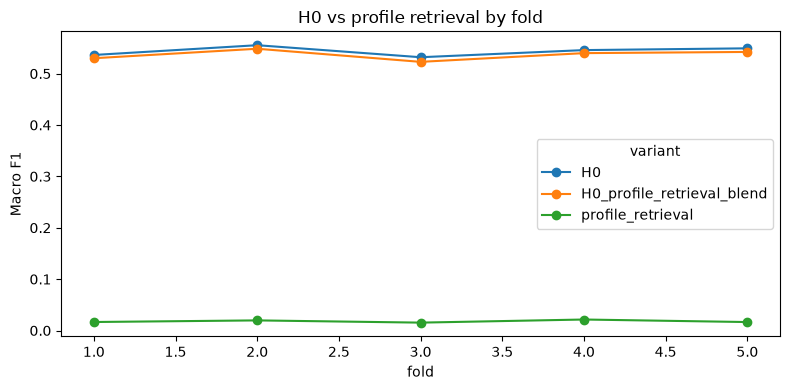

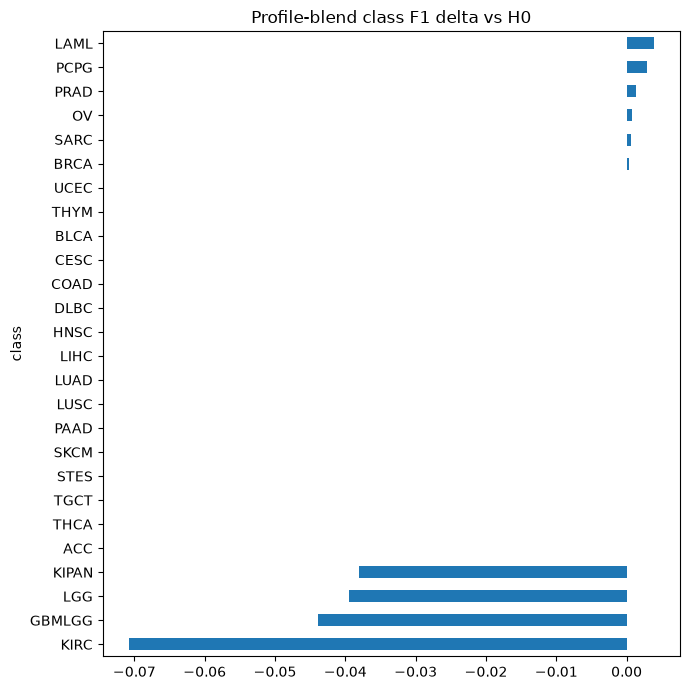

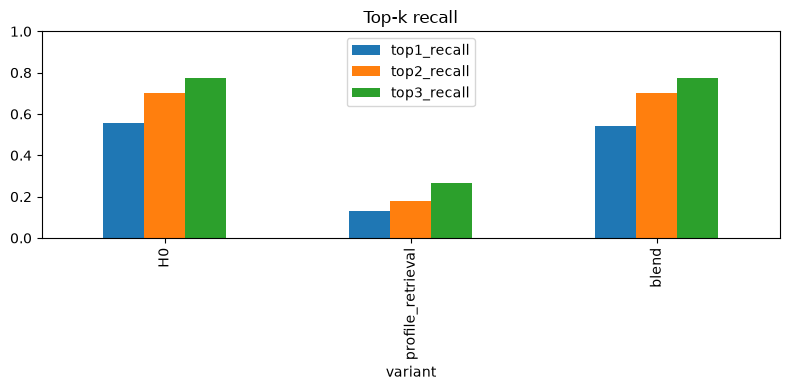

In [3]:
import json
import matplotlib.pyplot as plt
import pandas as pd

summary = pd.read_csv(RESULT / f'{RUN_ID}_seed42_summary.csv')
folds = pd.read_csv(RESULT / f'{RUN_ID}_seed42_fold_metrics.csv')
profiles = pd.read_csv(RESULT / f'{RUN_ID}_seed42_profile_audit.csv')
classes = pd.read_csv(RESULT / f'{RUN_ID}_seed42_class_metrics.csv')
topk = pd.read_csv(RESULT / f'{RUN_ID}_seed42_topk.csv')
low_margin = pd.read_csv(RESULT / f'{RUN_ID}_seed42_low_margin.csv')
audit = json.loads((RESULT / f'{RUN_ID}_seed42_leakage_audit.json').read_text())
assert summary.leakage_check.all() and summary.nan_as_mutation_count.eq(0).all()
display(summary.sort_values('oof_macro_f1', ascending=False))
display(profiles)
display(low_margin)
print('자동 판정:', audit['decision'])
print({key: audit[key] for key in ('matched_rate', 'retrieval_recovered_rows', 'retrieval_broken_rows', 'positive_fold_count', 'delta_vs_h0')})

folds.pivot(index='fold', columns='variant', values='macro_f1').plot(marker='o', figsize=(8, 4), title='H0 vs profile retrieval by fold')
plt.ylabel('Macro F1'); plt.tight_layout(); plt.show()
classes.set_index('class').blend_delta_vs_h0.sort_values().plot.barh(figsize=(7, 7), title='Profile-blend class F1 delta vs H0')
plt.tight_layout(); plt.show()
topk.set_index('variant')[['top1_recall', 'top2_recall', 'top3_recall']].plot.bar(figsize=(8, 4), title='Top-k recall')
plt.ylim(0, 1); plt.tight_layout(); plt.show()